In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectPercentile, chi2
from sklearn.preprocessing import OneHotEncoder, normalize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
import umap
from scipy.sparse import hstack
import optuna
from calidad_pqrs.utils import load_directory, load_data, drop_data, mapping_data, define_service, define_f3, clean_text_TfIdf, save_model, build_predictions_dataframe, load_model, optimize_threshold
from calidad_pqrs.config import MODEL_CAUSES_DIR

c:\Users\luisarmz\OneDrive - Seguros Suramericana, S.A\Documentos\2025\S2\Calidad PQRS\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Peprocesamiento

In [8]:
paths = load_directory(directory='Train')

In [9]:
data = load_data(paths)

Leyendo las descripciones de las quejas...


In [3]:
data = drop_data(data)
data = mapping_data(data)

Homologando procesos y causas con poca participación...


In [4]:
data_procesada = clean_text_TfIdf(data)

Removiendo categorías gramaticales que aportan poca información...
Lematizando palabras y removiendo stopwords...


In [5]:
data_procesada['Filtro 4_map'] = data_procesada.apply(define_service, axis=1)
data_procesada['Filtro 3_map'] = data_procesada['Filtro 3'].apply(define_f3)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    data_procesada[['Descripción_TfIdf', 'Proceso', 'Filtro 4_map', 'Filtro 3_map']],
    data_procesada['Causa'],
    test_size = 0.2,
    shuffle = True,
    random_state= 666,
)

In [14]:
display(
    len(y_train.value_counts(normalize=True)),
    len(y_test.value_counts(normalize=True))
)

37

37

### Representación visual de las clases

c:\Users\luisarmz\OneDrive - Seguros Suramericana, S.A\Documentos\2025\S2\Calidad PQRS\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


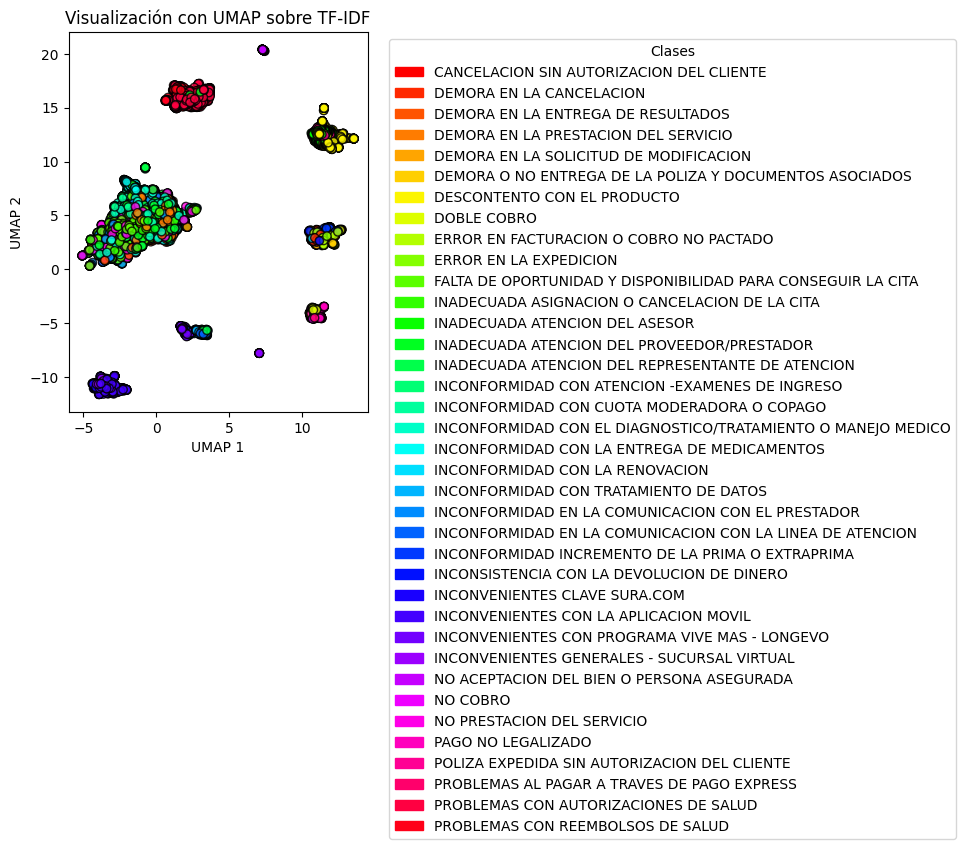

In [9]:
tfidf = TfidfVectorizer(decode_error='ignore')
X_tfidf = tfidf.fit_transform(data_procesada['Descripción_TfIdf'])

ohe = OneHotEncoder(drop='if_binary', handle_unknown='ignore')
X_ohe = ohe.fit_transform(data_procesada[['Proceso']])

X_combined = hstack([X_tfidf, X_ohe])
X_combined = normalize(X_combined, norm='l2', axis=1)

umap_model = umap.UMAP(n_components=2, random_state=666)
X_umap = umap_model.fit_transform(X_combined)

y = data_procesada['Causa'].astype('category')
categories = y.cat.categories
codes = y.cat.codes.values
colors = plt.cm.hsv(np.linspace(0, 1, len(categories)))


plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=colors[codes], alpha=0.8, edgecolor='k')
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("Visualización con UMAP sobre TF-IDF")

patches = [
    mpatches.Patch(color=colors[i], label=cat)
    for i, cat in enumerate(categories)
]

plt.legend(handles=patches, title="Clases", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [10]:
display(
    data_procesada.shape,
    X_combined.shape
)

(22928, 12)

(22928, 37759)

### clasificación con regresión logística

In [11]:
def objective_lr(trial):
    
    min_df = trial.suggest_float('min_df', 1e-5, 9e-4)
    C = trial.suggest_float('C', 9e-1, 1e1)
    percentile = trial.suggest_int('percentile', 40, 100)
    
    
    preprocessor = ColumnTransformer(
        transformers = [
            ('tfidf', TfidfVectorizer(decode_error='ignore', min_df=min_df, max_df=0.8), 'Descripción_TfIdf'),
            ('ohe', OneHotEncoder(drop='if_binary', handle_unknown='ignore'), ['Proceso',  'Filtro 4_map', 'Filtro 3_map']),
        ]
    )

    pipe = Pipeline(
        [
            ('preprocessor', preprocessor),
            ('select', SelectPercentile(score_func=chi2, percentile=percentile)),
            ('classifier', LogisticRegression(random_state=666, n_jobs=-1, max_iter=7000, class_weight='balanced', penalty='l2', solver='liblinear', C=C))
        ]
    )

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=666)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)

    return scores.mean()


study = optuna.create_study(
    direction='maximize', 
    study_name='pipeline_optimization_lr'
)

study.optimize(objective_lr, n_trials=99)

[I 2026-02-09 18:53:26,713] A new study created in memory with name: pipeline_optimization_lr
c:\Users\luisarmz\OneDrive - Seguros Suramericana, S.A\Documentos\2025\S2\Calidad PQRS\.venv\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
[I 2026-02-09 18:53:47,426] Trial 0 finished with value: 0.716317247330236 and parameters: {'min_df': 0.000557756590953067, 'C': 5.150244958850105, 'percentile': 66}. Best is trial 0 with value: 0.716317247330236.
c:\Users\luisarmz\OneDrive - Seguros Suramericana, S.A\Documentos\2025\S2\Calidad PQRS\.venv\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
[I 2026-02-09 18:54:04,175] Trial 1 finished with value: 0.7130853587835152 and parameters: {'min_df': 0.0007912961884892016, 'C': 9.416684823077425, 'percentile': 83}.

In [12]:
print(f'Mejor score: {study.best_value:.4f}')
best_params = study.best_params

best_params

Mejor score: 0.7229


{'min_df': 0.0008438065964597782, 'C': 3.758252327640125, 'percentile': 51}

In [13]:
preprocessor = ColumnTransformer(
    transformers = [
        ('tfidf', TfidfVectorizer(decode_error='ignore', min_df=best_params['min_df'], max_df=0.8), 'Descripción_TfIdf'),
        ('ohe', OneHotEncoder(drop='if_binary', handle_unknown='ignore'), ['Proceso', 'Filtro 4_map', 'Filtro 3_map']),
    ]
)

model_causes = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('select', SelectPercentile(score_func=chi2, percentile=best_params['percentile'])),
        ('classifier', LogisticRegression(random_state=666, n_jobs=-1, max_iter=7000, class_weight='balanced', penalty='l2', solver='liblinear', C=best_params['C']))
    ]
)

model_causes.fit(X_train, y_train)

c:\Users\luisarmz\OneDrive - Seguros Suramericana, S.A\Documentos\2025\S2\Calidad PQRS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 12.
  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('tfidf',
                                                  TfidfVectorizer(decode_error='ignore',
                                                                  max_df=0.8,
                                                                  min_df=0.0008438065964597782),
                                                  'Descripción_TfIdf'),
                                                 ('ohe',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore'),
                                                  ['Proceso', 'Filtro 4_map',
                                                   'Filtro 3_map'])])),
                ('select',
                 SelectPercentile(percentile=51,
                                  score_func=<function chi2 at 0x0000014BAA82A5C0>)),
                ('classifier',
                 LogisticRegression(C=3.758252327640125,
                                    class_weight='balanced', max_iter=7000,
                                    n_jobs=-1, random_state=666,
                                    solver='liblinear'))])

In [16]:
y_pred_train = model_causes.predict(X_train)
y_pred_test = model_causes.predict(X_test)

print('balanced accuracy train:', balanced_accuracy_score(y_train, y_pred_train))
print('balanced accuracy test:', balanced_accuracy_score(y_test, y_pred_test))
print('f1 score train (weighted):', f1_score(y_train, y_pred_train, average='weighted'))
print('f1 score test (weighted):', f1_score(y_test, y_pred_test, average='weighted'))
print('f1 score train (macro):', f1_score(y_train, y_pred_train, average='macro'))
print('f1 score test (macro):', f1_score(y_test, y_pred_test, average='macro'))

print('\nscore train:', model_causes.score(X_train, y_train))
print('score test:', model_causes.score(X_test, y_test))

balanced accuracy train: 0.9177830095235548
balanced accuracy test: 0.7687662422167728
f1 score train (weighted): 0.8517318856319966
f1 score test (weighted): 0.7572726187041355
f1 score train (macro): 0.904922441480139
f1 score test (macro): 0.7502259929850613

score train: 0.8527423399847345
score test: 0.7592673353685129


In [16]:
save_model(
    model = model_causes,
    model_dir = MODEL_CAUSES_DIR,
    model_name = 'salud_causes_classifier.pkl',
    X_test = X_test,
    y_test = y_test
)

Nuevo modelo guardado.
Score nuevo modelo: 0.7509234816127397
Score nuevo anterior: None


In [17]:
tfidf_model = load_model(MODEL_CAUSES_DIR, 'salud_causes_classifier.pkl')

In [18]:
y_pred_train = tfidf_model.predict(X_train)
y_pred_test = tfidf_model.predict(X_test)

print('balanced accuracy train:', balanced_accuracy_score(y_train, y_pred_train))
print('balanced accuracy test:', balanced_accuracy_score(y_test, y_pred_test))
print('f1 score train (weighted):', f1_score(y_train, y_pred_train, average='weighted'))
print('f1 score test (weighted):', f1_score(y_test, y_pred_test, average='weighted'))
print('f1 score train (macro):', f1_score(y_train, y_pred_train, average='macro'))
print('f1 score test (macro):', f1_score(y_test, y_pred_test, average='macro'))

print('\nscore train:', tfidf_model.score(X_train, y_train))
print('score test:', tfidf_model.score(X_test, y_test))

balanced accuracy train: 0.9209110914352283
balanced accuracy test: 0.7693164939142613
f1 score train (weighted): 0.8569337703044873
f1 score test (weighted): 0.761499490123204
f1 score train (macro): 0.9087576777346872
f1 score test (macro): 0.7509234816127397

score train: 0.8578671900556101
score test: 0.7631923244657653


In [ ]:
predictions_dataframe = build_predictions_dataframe(
    model = tfidf_model,
    X_test = X_test,
    true_class_col = 'clase real',
    y_test = y_test,
    predicted_class_col = 'clase predicha',
    dataset_original = data_procesada,
    drop_cols = 'Causa'
    )

In [20]:
thresholds = optimize_threshold(
    dataset = predictions_dataframe,
    threshold_error = 0.13
)

thresholds

,Clase,Umbral,Falsos que pasan (%),Verdaderos que pasan (%)
0,FALTA DE OPORTUNIDAD Y DISPONIBILIDAD PARA CON...,0.7735,0.12,0.48
1,NO PRESTACION DEL SERVICIO,0.6535,0.13,0.51
2,CANCELACION SIN AUTORIZACION DEL CLIENTE,0.447,0.12,0.78
3,INADECUADA ATENCION DEL PROVEEDOR/PRESTADOR,0.7335,0.12,0.49
4,INADECUADA ATENCION DEL ASESOR,0.8334,0.11,0.59
5,DEMORA EN LA PRESTACION DEL SERVICIO,0.7515,0.13,0.38
6,INCONVENIENTES CON LA APLICACION MOVIL,0.9017,0.12,0.43
7,DESCONTENTO CON EL PRODUCTO,0.8506,0.12,0.59
8,ERROR EN FACTURACION O COBRO NO PACTADO,0.5282,0.11,0.66
9,INADECUADA ASIGNACION O CANCELACION DE LA CITA,0.7434,0.12,0.51


In [21]:
predictions_dataframe.to_excel('../Output/resultados_causas_lr.xlsx', index=False)

### Random Forest Classifier

In [ ]:
# probabilities = tfidf_model.predict_proba(data_procesada[['Descripción_TfIdf', 'Proceso']])

# probabilities_df = pd.DataFrame(probabilities, columns=prob_cols, index=data_procesada.index)

In [ ]:
# data_procesada_proba = data_procesada.join(probabilities_df, how='left')

# data_procesada_proba_p = [col for col in data_procesada_proba.columns if col.startswith('prob_')]
# data_procesada_proba_cos = [col for col in data_procesada_proba.columns if col.startswith('cos_sim_')]

In [ ]:
# X_train_svc, X_test_svc, y_train_svc, y_test_svc = train_test_split(
#     data_procesada_proba[data_procesada_proba_cos + data_procesada_proba_p],
#     data_procesada['Causa'],
#     test_size = 0.2,
#     shuffle = True,
#     random_state= 666,
# )

In [ ]:
# display(
#     len(y_train_svc.value_counts(normalize=True)),
#     len(y_test_svc.value_counts(normalize=True))
# )

In [ ]:
# def objective_svc(trial):
    
#     n_estimators = trial.suggest_int('n_estimators', 100, 300)
#     max_features = trial.suggest_int('max_features', 16, len(X_train_svc.columns))
#     min_impurity_decrease = trial.suggest_float('min_impurity_decrease', 1e-6, 1e-3, log=True)
    
#     model = RandomForestClassifier(random_state=666, class_weight='balanced', n_jobs=-1, n_estimators=n_estimators, max_features=max_features, min_impurity_decrease=min_impurity_decrease)

#     cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=666)
#     scores = cross_val_score(model, X_train_svc, y_train_svc, cv=cv, scoring='f1_macro', n_jobs=-1)

#     return scores.mean()


# study_scv = optuna.create_study(
#     direction='maximize', 
#     study_name='pipeline_optimization'
# )

# study_scv.optimize(objective_svc, n_trials=11)

In [ ]:
# print(f'Mejor score: {study_scv.best_value:.4f}')
# best_params_svc = study_scv.best_params

# best_params_svc

In [ ]:
# svc_model = RandomForestClassifier(random_state=666, class_weight='balanced', n_jobs=-1, n_estimators=best_params_svc['n_estimators'], max_features=best_params_svc['max_features'], min_impurity_decrease=best_params_svc['min_impurity_decrease'])

# svc_model.fit(X_train_svc, y_train_svc)

In [ ]:
# y_pred_train = svc_model.predict(X_train_svc)
# y_pred_test = svc_model.predict(X_test_svc)

# print('balanced accuracy train:', balanced_accuracy_score(y_train_svc, y_pred_train))
# print('balanced accuracy test:', balanced_accuracy_score(y_test_svc, y_pred_test))
# print('f1 score train (weighted):', f1_score(y_train_svc, y_pred_train, average='weighted'))
# print('f1 score test (weighted):', f1_score(y_test_svc, y_pred_test, average='weighted'))
# print('f1 score train (macro):', f1_score(y_train_svc, y_pred_train, average='macro'))
# print('f1 score test (macro):', f1_score(y_test_svc, y_pred_test, average='macro'))

# print('\nscore train:', svc_model.score(X_train_svc, y_train_svc))
# print('score test:', svc_model.score(X_test_svc, y_test_svc))

In [ ]:
# save_model(
#     model = svc_model,
#     model_dir = MODEL_CAUSES_DIR,
#     model_name = 'salud_causes_classifier.pkl',
#     X_test = X_test,
#     y_test = y_test
# )

In [ ]:
# cossim_model = load_model(MODEL_CAUSES_DIR, 'salud_causes_classifier.pkl')

In [ ]:
# resultados_svc = pd.DataFrame({
#     'clase_real': y_test_svc.values,
#     'clase_predicha': cossim_model.predict(X_test_svc)
# }, index=X_test_svc.index)

In [ ]:
# final_svc = (
#     resultados_svc
#     .join(final_lr.drop(columns=['clase_real', 'clase_predicha']), how='left')
# )

In [ ]:
# final_svc.to_excel('../Output/resultados_causas_rf.xlsx', index=False)